In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Huber
import matplotlib.pyplot as plt

# Download data
ticker = "QQQ"
df = yf.download(ticker, start="2015-01-01")

# Use multiple features
features = ["Open", "High", "Low", "Close", "Volume"]
data = df[features].values

# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences
window = 120

X, y = [], []
for i in range(window, len(scaled_data)):
    X.append(scaled_data[i-window:i])
    y.append(scaled_data[i][3])  # Predict Close price

X, y = np.array(X), np.array(y)

# Train/Test split (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

C:\Users\16786\AppData\Local\Temp\ipykernel_1668\949782851.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01")
[*********************100%***********************]  1 of 1 completed


In [2]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ
Date,,,,,
2026-02-23,601.409973,608.010010,599.049988,606.609985,63859100
2026-02-24,607.869995,608.989990,599.729980,602.400024,55023700
2026-02-25,616.679993,616.830017,611.000000,611.070007,55710700
2026-02-26,609.239990,615.590027,603.979980,615.590027,96178900
2026-02-27,607.289978,608.320007,602.190002,602.979980,68012000


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"

# ===== model =====
class LSTMModel(nn.Module):
    def __init__(self,input_size):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size,128,batch_first=True)
        self.drop1 = nn.Dropout(0.1)

        self.lstm2 = nn.LSTM(128,128,batch_first=True)
        self.drop2 = nn.Dropout(0.1)

        self.lstm3 = nn.LSTM(128,64,batch_first=True)
        self.fc = nn.Linear(64,1)

    def forward(self,x):
        x,_ = self.lstm1(x)
        x = self.drop1(x)

        x,_ = self.lstm2(x)
        x = self.drop2(x)

        x,_ = self.lstm3(x)

        return self.fc(x[:,-1])


model = LSTMModel(X.shape[2]).to(device)

loss_fn = nn.HuberLoss()
opt = torch.optim.Adam(model.parameters())

# ===== data =====
train_ds = TensorDataset(
    torch.tensor(X_train,dtype=torch.float32),
    torch.tensor(y_train,dtype=torch.float32).unsqueeze(1)
)

loader = DataLoader(train_ds,batch_size=32,shuffle=True)

# ===== training =====
best_loss = float("inf")
patience = 10
counter = 0

for epoch in range(120):

    model.train()
    total=0

    for xb,yb in loader:
        xb,yb = xb.to(device),yb.to(device)

        pred = model(xb)
        loss = loss_fn(pred,yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()

    print(epoch,total)

    # early stopping
    if total < best_loss:
        best_loss = total
        best_weights = model.state_dict()
        counter=0
    else:
        counter+=1
        if counter>=patience:
            print("Early stop")
            break

model.load_state_dict(best_weights)

0 0.4550912058330141
1 0.009100882889470086
2 0.007763401234115008
3 0.008007398322661174
4 0.008348257058969466
5 0.006767301721993135
6 0.007018452419288224
7 0.007481959673896199
8 0.006614876014282345
9 0.00753950484431698
10 0.006613124442083063
11 0.0057379984100407455
12 0.005912870497922995
13 0.006520561648358125
14 0.007166272167523857
15 0.005378453923640336
16 0.00602428429738211
17 0.004933693626298918
18 0.00567823010351276
19 0.005451193024782697
20 0.005661265673552407
21 0.004664229394620634
22 0.004844301864068257
23 0.005924531338678207
24 0.006175196356707602
25 0.0053413785662996816
26 0.004730589007522212
27 0.006093382613471476
28 0.005084422657091636
29 0.004338263986937818
30 0.00480123466331861
31 0.004202266260108445
32 0.0042938666465488495
33 0.004989925642803428
34 0.005689501913366257
35 0.004012791303466656
36 0.0035888700003852136
37 0.003420799739615177
38 0.004255817733792355
39 0.0039510065216745716
40 0.0036436153804970672
41 0.00434878632404434
42 

<All keys matched successfully>

In [4]:
model.eval()

with torch.no_grad():
    pred = model(torch.tensor(X_test,dtype=torch.float32).to(device)).cpu().numpy()

# Reconstruct full feature array for inverse scaling
temp = np.zeros((len(pred), len(features)))
temp[:, 3] = pred.flatten()   # Put predicted Close in correct column
pred_prices = scaler.inverse_transform(temp)[:, 3]

# Real prices
temp_real = np.zeros((len(y_test), len(features)))
temp_real[:, 3] = y_test
real_prices = scaler.inverse_transform(temp_real)[:, 3]

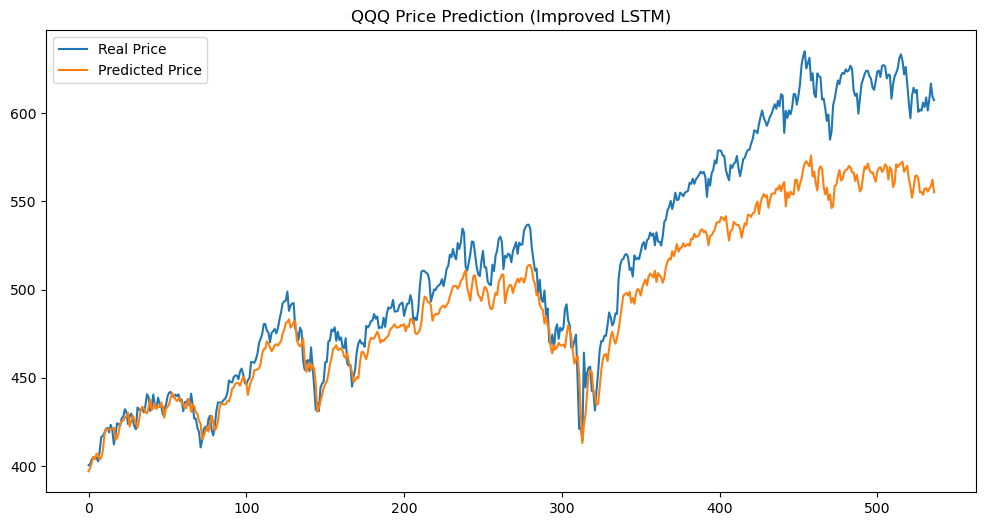

In [5]:
plt.figure(figsize=(12,6))
plt.plot(real_prices, label="Real Price")
plt.plot(pred_prices, label="Predicted Price")
plt.legend()
plt.title(f"{ticker} Price Prediction (Improved LSTM)")
plt.show()

In [6]:
def predict_next_day(model, scaler, df, features, window):

    last_data = df[features].values[-window:]
    last_scaled = scaler.transform(last_data)
    last_scaled = torch.tensor(last_scaled,dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_scaled = model(last_scaled).cpu().numpy()

    temp = np.zeros((1,len(features)))
    temp[:,3] = pred_scaled.flatten()
    pred_price = scaler.inverse_transform(temp)[0,3]

    return float(pred_price)

In [7]:
tomorrow_price = predict_next_day(model, scaler, df, features, window)
print("Predicted next close:", tomorrow_price)

Predicted next close: 559.4745657989915


In [8]:
# torch.save(model.state_dict(),"models/lstm.pth")